In [1]:
import os
import tqdm
import time
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.optim.lr_scheduler import _LRScheduler
import torch.optim as optim
from torch.utils import data as torch_data

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
from sklearn.metrics import classification_report

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import copy

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


# DatacenterDataset code

In [4]:
class DatacenterDataset(Dataset):
    def __init__(self, src, trg, class_names):
        self.src = torch.tensor(src, dtype=torch.float32)
        self.trg = torch.tensor(trg, dtype=torch.long)
        self.class_names = class_names

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.trg[idx]

In [5]:
class DatacenterTwoTowerDataset(torch_data.Dataset):
    def __init__(self, X_gpu, X_cpu, y, class_names):
        self.X_gpu = torch.tensor(X_gpu, dtype=torch.float32)
        self.X_cpu = torch.tensor(X_cpu, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.class_names = class_names

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_gpu[idx], self.X_cpu[idx], self.y[idx]

# Load ML Data


In [6]:
seed = 2022
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

max_workers = 0
batch_size = 32

In [7]:
def split_data_combined_dataset(npz_path):

  ml_data = np.load(npz_path)
  X, y, model = ml_data["X"], ml_data["y"], ml_data["model"]

  print(X.shape, y.shape, model.shape)

  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values("y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # First split: train+val vs test
  sss1 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=37
  )

  for train_val_idx, test_idx in sss1.split(X, y):
      X_train_val, X_test = X[train_val_idx], X[test_idx]
      y_train_val, y_test = y[train_val_idx], y[test_idx]

  # Second split: train vs validation
  sss2 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=38
  )

  for train_idx, val_idx in sss2.split(X_train_val, y_train_val):
      X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
      y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

  print("Train:", X_train.shape, y_train.shape)
  print("Val:  ", X_val.shape, y_val.shape)
  print("Test: ", X_test.shape, y_test.shape)

  n_classes = len(np.unique(y_train))

  # Standardize using train only
  scaler = StandardScaler()

  X_train = scaler.fit_transform(
      X_train.reshape(-1, X_train.shape[-1])
  ).reshape(X_train.shape)

  X_val = scaler.transform(
      X_val.reshape(-1, X_val.shape[-1])
  ).reshape(X_val.shape)

  X_test = scaler.transform(
      X_test.reshape(-1, X_test.shape[-1])
  ).reshape(X_test.shape)

  # Build datasets
  dset_train = DatacenterDataset(X_train, y_train, class_names)
  dset_val = DatacenterDataset(X_val, y_val, class_names)
  dset_test = DatacenterDataset(X_test, y_test, class_names)

  train_dl_combined = torch_data.DataLoader(
      dset_train,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=True
  )

  val_dl_combined = torch_data.DataLoader(
      dset_val,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  test_dl_combined = torch_data.DataLoader(
      dset_test,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )
  return train_dl_combined, val_dl_combined, test_dl_combined

In [8]:
def split_data_separate_dataset(npz_path):

  ml_data = np.load(npz_path)
  X_gpu = ml_data["X_gpu"]
  X_cpu = ml_data["X_cpu"]
  y = ml_data["y"]
  model = ml_data["model"]

  print(X_gpu.shape, X_cpu.shape, y.shape, model.shape)

  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values("y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # First split: train+val vs test
  sss1 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=37
  )

  for train_val_idx, test_idx in sss1.split(X_gpu, y):
      X_gpu_train_val, X_gpu_test = X_gpu[train_val_idx], X_gpu[test_idx]
      X_cpu_train_val, X_cpu_test = X_cpu[train_val_idx], X_cpu[test_idx]
      y_train_val, y_test = y[train_val_idx], y[test_idx]
      model_train_val, model_test = model[train_val_idx], model[test_idx]

  # Second split: train vs validation
  sss2 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=38
  )

  for train_idx, val_idx in sss2.split(X_gpu_train_val, y_train_val):
      X_gpu_train, X_gpu_val = X_gpu_train_val[train_idx], X_gpu_train_val[val_idx]
      X_cpu_train, X_cpu_val = X_cpu_train_val[train_idx], X_cpu_train_val[val_idx]
      y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]
      model_train, model_val = model_train_val[train_idx], model_train_val[val_idx]

  print("GPU train:", X_gpu_train.shape)
  print("CPU train:", X_cpu_train.shape)
  print("y train:  ", y_train.shape)

  print("GPU val:", X_gpu_val.shape)
  print("CPU val:", X_cpu_val.shape)
  print("y val:  ", y_val.shape)

  print("GPU test:", X_gpu_test.shape)
  print("CPU test:", X_cpu_test.shape)
  print("y test:  ", y_test.shape)

  n_classes = len(np.unique(y_train))

  gpu_scaler = StandardScaler()
  cpu_scaler = StandardScaler()

  X_gpu_train = gpu_scaler.fit_transform(
      X_gpu_train.reshape(-1, X_gpu_train.shape[-1])
  ).reshape(X_gpu_train.shape)

  X_gpu_val = gpu_scaler.transform(
      X_gpu_val.reshape(-1, X_gpu_val.shape[-1])
  ).reshape(X_gpu_val.shape)

  X_gpu_test = gpu_scaler.transform(
      X_gpu_test.reshape(-1, X_gpu_test.shape[-1])
  ).reshape(X_gpu_test.shape)


  X_cpu_train = cpu_scaler.fit_transform(
      X_cpu_train.reshape(-1, X_cpu_train.shape[-1])
  ).reshape(X_cpu_train.shape)

  X_cpu_val = cpu_scaler.transform(
      X_cpu_val.reshape(-1, X_cpu_val.shape[-1])
  ).reshape(X_cpu_val.shape)

  X_cpu_test = cpu_scaler.transform(
      X_cpu_test.reshape(-1, X_cpu_test.shape[-1])
  ).reshape(X_cpu_test.shape)

  dset_train = DatacenterTwoTowerDataset(X_gpu_train, X_cpu_train, y_train, class_names)
  dset_val = DatacenterTwoTowerDataset(X_gpu_val, X_cpu_val, y_val, class_names)
  dset_test = DatacenterTwoTowerDataset(X_gpu_test, X_cpu_test, y_test, class_names)

  train_dl_sep = torch_data.DataLoader(
      dset_train,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=True
  )

  val_dl_sep = torch_data.DataLoader(
      dset_val,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  test_dl_sep = torch_data.DataLoader(
      dset_test,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  return train_dl_sep, val_dl_sep, test_dl_sep

In [9]:
data_directory_path_combined = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/COMBINED"
data_directory_path_separate = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/SEPARATE"

combined_datasets = []
separated_datasets = []

for _file in os.listdir(data_directory_path_combined):
  if not _file.endswith(".npz"):
    continue
  _filepath = os.path.join(data_directory_path_combined, _file)
  train_dl_combined, val_dl_combined, test_dl_combined = split_data_combined_dataset(_filepath)
  combined_datasets.append({"name": _file, "train_dl": train_dl_combined, "val_dl": val_dl_combined, "test_dl": test_dl_combined})

for _file in os.listdir(data_directory_path_separate):
  if not _file.endswith(".npz"):
    continue
  _filepath = os.path.join(data_directory_path_separate, _file)
  train_dl_separate, val_dl_separate, test_dl_separate = split_data_separate_dataset(_filepath)
  separated_datasets.append({"name": _file, "train_dl": train_dl_separate, "val_dl": val_dl_separate, "test_dl": test_dl_separate})



(18238, 540, 15) (18238,) (18238,)
Train: (11672, 540, 15) (11672,)
Val:   (2918, 540, 15) (2918,)
Test:  (3648, 540, 15) (3648,)
(17767, 540, 15) (17767,) (17767,)
Train: (11370, 540, 15) (11370,)
Val:   (2843, 540, 15) (2843,)
Test:  (3554, 540, 15) (3554,)
(17728, 540, 15) (17728,) (17728,)
Train: (11345, 540, 15) (11345,)
Val:   (2837, 540, 15) (2837,)
Test:  (3546, 540, 15) (3546,)
(17725, 540, 15) (17725,) (17725,)
Train: (11344, 540, 15) (11344,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17741, 540, 15) (17741,) (17741,)
Train: (11353, 540, 15) (11353,)
Val:   (2839, 540, 15) (2839,)
Test:  (3549, 540, 15) (3549,)
(17724, 540, 15) (17724,) (17724,)
Train: (11343, 540, 15) (11343,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17733, 540, 15) (17733,) (17733,)
Train: (11348, 540, 15) (11348,)
Val:   (2838, 540, 15) (2838,)
Test:  (3547, 540, 15) (3547,)
(18238, 540, 7) (18238, 7, 8) (18238,) (18238,)
GPU train: (11672, 540, 7)
CPU train: (116

In [10]:
class_names_combined = test_dl_combined.dataset.class_names
print(class_names_combined)

['U3-128' 'U3-32' 'U3-64' 'U4-128' 'U4-32' 'U4-64' 'U5-128' 'U5-32'
 'U5-64' 'bert-base-uncased' 'conv' 'dimenet' 'distilbert-base-uncased'
 'inception3' 'inception4' 'pna' 'resnet101' 'resnet101_v2' 'resnet152'
 'resnet152_v2' 'resnet50' 'resnet50_v1.5' 'schnet' 'vgg11' 'vgg16'
 'vgg19']


In [11]:
class_names_separate = test_dl_separate.dataset.class_names
print(class_names_separate)

['U3-128' 'U3-32' 'U3-64' 'U4-128' 'U4-32' 'U4-64' 'U5-128' 'U5-32'
 'U5-64' 'bert-base-uncased' 'conv' 'dimenet' 'distilbert-base-uncased'
 'inception3' 'inception4' 'pna' 'resnet101' 'resnet101_v2' 'resnet152'
 'resnet152_v2' 'resnet50' 'resnet50_v1.5' 'schnet' 'vgg11' 'vgg16'
 'vgg19']


# Define Model(s)

In [12]:
class PositionalEncoding(nn.Module):
  """
  Transformers process sequences all at once, so they lack inherent knowledge
  of token order. We must inject some information about the relative and absolute
  position of the tokens in the sequence. In this function, we add fixed positional
  encoding vector using sine and cosine waves.
  """
  def __init__(self, transform_embed_dim, dropout=0.0, max_len=5000):
    """
    Args:
      transform_embed_dim: the embed dimension.
      dropout: the dropout value.
      max_len: the maximum length of the incoming sequence.
    """

    super().__init__()

    self.dropout = nn.Dropout(p=dropout)

    pe = torch.zeros(max_len, transform_embed_dim)
    # pe shape: [max_len, transform_embed_dim]

    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    # position shape: [max_len, 1]

    div_term = torch.exp(
        torch.arange(0, transform_embed_dim, 2).float()
        * (-math.log(10000.0) / transform_embed_dim)
    )
    # div_term shape: [ceil(transform_embed_dim / 2)]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
    # `[:pe[:, 1::2].shape[1]]` makes the code safer if `transform_embed_dim` is odd.
    # Ex. if `transform_embed_dim` == 15, the sine side has 8 dimensions and the cosine side
    # has 7 dimensions. This prevents a shape mismatch.

    # Add batch dimension so it can broadcast across batch:
    # [1, max_len, transform_embed_dim]
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    """
    Args:
      x: the sequence fed to the positional encoder model.

    Input shape:
        x: [batch_size, seq_len, transform_embed_dim]

    Output shape:
        x + positional encoding: [batch_size, seq_len, transform_embed_dim]

    Examples:
      >>> output = pos_encoder(x)
    """
    seq_len = x.size(1)
    x = x + self.pe[:, :seq_len, :]
    return self.dropout(x)

In [13]:
def compute_summary_stats(x):
    """
    x shape: (batch_size, seq_len, input_dim)

    Returns:
        stats shape: (batch_size, 4 * input_dim)
    """
    x_mean = x.mean(dim=1)
    x_std = x.std(dim=1, unbiased=False)
    x_max = x.max(dim=1).values
    x_min = x.min(dim=1).values

    stats = torch.cat([x_mean, x_std, x_max, x_min], dim=1)

    return stats

In [14]:
class TransformerModel(nn.Module):
  """
  This model is a simple time-series Transformer classifier. For a sequence
  classification (many-to-one) an encoder-only structure is needed.

    input time series -> encode sequence -> summarize sequence -> classify

  Overall, this transformer model has the following structure:

    [number of batches, 540 time steps, 15 features (7 GPU + 8 CPU features)]
              ↓
    linear projection to embedding space
              ↓
    positional encoding
              ↓
    transformer encoding
              ↓
    pool over time
              ↓
    linear classifier
              ↓
    DNN model class

  What this model is doing:
    Each row of the time series is first converted from 15 raw sensor features
    into a richer dimensional representation.

    Then positional encoding tells the model where each time step occurs in the
    sequence.

    Then self-attention lets every time step compare itself to every other time
    step.

    Then the model averages all time-step representations into one job-level
    representation.

    Finally, a linear layer predicts which DNN model produced that
    resource-usage pattern.

  """

  def __init__(
      self,
      input_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=5000,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.input_projection = nn.Linear(
        in_features=input_dim,
        out_features=transform_embed_dim
    )

    # Add position information
    self.pos_encoder = PositionalEncoding(
        transform_embed_dim=transform_embed_dim,
        dropout=dropout,
        max_len=max_len
    )

    # One encoder layer
    encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True,
        activation="gelu",
        norm_first=True,
    )

    # Stack multiple encoder layers
    self.transformer_encoder = nn.TransformerEncoder(
        encoder_layer,
        num_layers=num_layers
    )

    # Final classifier
    pooled_dim = 2 * transform_embed_dim
    stats_dim = 4 * input_dim
    self.classifier = nn.Sequential(
        nn.LayerNorm(pooled_dim + stats_dim),
        nn.Linear(pooled_dim + stats_dim, 2 * transform_embed_dim),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(2 * transform_embed_dim, num_classes),
    )

  def forward(self, x):
    """
    Arg:
      x: Input sequence

    Input Shape:
      x: [batch_size, seq_len, input_dim]
    """
    raw_x = x

    # Transform raw input sequence to transformer embedding dimension
    # [batch_size, seq_len, 15] -> [batch_size, seq_len, transform_embed_dim]
    x = self.input_projection(x)

    # Add positional encoding
    x = self.pos_encoder(x)

    # Transformer encoder
    # output shape: [batch_size, seq_len, transform_embed_dim]
    x = self.transformer_encoder(x)

    # Pool over time
    # shape: [batch_size, 2* transform_embed_dim]
    mean_pool = x.mean(dim=1)
    max_pool = x.max(dim=1).values
    pooled = torch.cat([mean_pool, max_pool], dim=1)

    stats = compute_summary_stats(raw_x)

    h = torch.cat([pooled, stats], dim=1)

    # Classify
    # shape: [batch_size, num_classes]
    logits = self.classifier(h)

    return logits


In [27]:
class GatedTwoTowerTransformerModel(nn.Module):
  """
  This is a two-tower gated transformer architecture where GPU and CPU features
  are processed separately at first, then combined later.

  Overall this transformer model has the following structure:
            GPU features                                          CPU features
  [num of batches, 540 time steps, 7]                 [num of batches, 7-8 time steps, 8]
                  ↓                                                   ↓
            GPU input projection                            CPU input projection
                  ↓                                                   ↓
            GPU Transformer tower                           CPU Transformer tower
                  ↓                                                   ↓
            GPU representation                              CPU representation
                  ↓                                             ↓
                                gated fusion / combine layer
                                            ↓
                                      classifier head
                                            ↓
                                      DNN model class

  The reason this architecture may be helpful is because GPU and CPU signals
  carry different information.

  A gate is a learnable mechanism that decides how much to trust each tower.
  If gate is close to 1, the model relies more on GPU. If gate is close to 0,
  the model relies more on CPU. If it is around 0.5, it blends them.
  """
  def __init__(
      self,
      gpu_dim,
      cpu_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=540,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    self.gpu_input_dim = gpu_dim
    self.cpu_input_dim = cpu_dim
    self.transform_embed_dim = transform_embed_dim

    # GPU tower
    self.gpu_projection = nn.Linear(gpu_dim, transform_embed_dim)
    self.gpu_pos_encoder = PositionalEncoding(
        transform_embed_dim=transform_embed_dim,
        dropout=dropout,
        max_len=max_len,
    )

    gpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True,
        activation="gelu",
        norm_first=True,
    )

    self.gpu_transformer = nn.TransformerEncoder(
        gpu_encoder_layer,
        num_layers=num_layers,
    )

    # CPU tower
    self.cpu_projection = nn.Linear(cpu_dim, transform_embed_dim)
    self.cpu_pos_encoder = PositionalEncoding(
        transform_embed_dim=transform_embed_dim,
        dropout=dropout,
        max_len=max_len,
    )

    cpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True,
        activation="gelu",
        norm_first=True,
    )

    self.cpu_transformer = nn.TransformerEncoder(
        cpu_encoder_layer,
        num_layers=num_layers,
    )

    # Gate uses the learned GPU/CPU tower embeddings
    # Here each tower embedding uses mean+max pooling, so each is 2 * transform_embed_dim
    tower_dim = 2 * transform_embed_dim
    gate_input_dim = 2 * tower_dim

    self.gate = nn.Sequential(
        nn.Linear(gate_input_dim, tower_dim),
        nn.GELU(),
        nn.Linear(tower_dim, tower_dim),
        nn.Sigmoid(),
    )

    # Gated representation has dimension tower_dim
    gated_dim = tower_dim

    # Summary stats dimension
    stats_dim = 4 * gpu_dim + 4 * cpu_dim

    classifier_input_dim = gated_dim + stats_dim

    self.classifier = nn.Sequential(
        nn.LayerNorm(classifier_input_dim),
        nn.Linear(classifier_input_dim, 2 * transform_embed_dim),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(2 * transform_embed_dim, num_classes),
    )

  def forward(self, x_gpu, x_cpu):
    """
    Arg:
      x_gpu: Input GPU sequence
      x_cpu: Input CPU sequence

    Input Shape:
      x_gpu: [batch_size, seq_len, 7]
      x_cpu: [batch_size, seq_len, 8]
    """
    raw_gpu = x_gpu
    raw_cpu = x_cpu

    # GPU tower
    h_gpu = self.gpu_projection(x_gpu)
    h_gpu = self.gpu_pos_encoder(h_gpu)
    h_gpu = self.gpu_transformer(h_gpu)

    gpu_mean = h_gpu.mean(dim=1)
    gpu_max = h_gpu.max(dim=1).values
    gpu_repr = torch.cat([gpu_mean, gpu_max], dim=1)

    # CPU tower
    h_cpu = self.cpu_projection(x_cpu)
    h_cpu = self.cpu_pos_encoder(h_cpu)
    h_cpu = self.cpu_transformer(h_cpu)

    cpu_mean = h_cpu.mean(dim=1)
    cpu_max = h_cpu.max(dim=1).values
    cpu_repr = torch.cat([cpu_mean, cpu_max], dim=1)

    # Gate between GPU and CPU learned representations
    gate_input = torch.cat([gpu_repr, cpu_repr], dim=1)
    gate = self.gate(gate_input)

    gated_repr = gate * gpu_repr + (1.0 - gate) * cpu_repr

    # Raw summary stats
    gpu_stats = compute_summary_stats(raw_gpu)
    cpu_stats = compute_summary_stats(raw_cpu)
    stats = torch.cat([gpu_stats, cpu_stats], dim=1)

    # Final representation
    h = torch.cat([gated_repr, stats], dim=1)

    logits = self.classifier(h)

    return logits

In [23]:
class TwoTowerTransformerModel(nn.Module):
  def __init__(
      self,
      gpu_dim,
      cpu_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=540,
  ):
    super().__init__()

    self.gpu_dim = gpu_dim
    self.cpu_dim = cpu_dim

    self.gpu_projection = nn.Linear(
        in_features=gpu_dim,
        out_features=transform_embed_dim
    )
    self.cpu_projection = nn.Linear(
        in_features=cpu_dim,
        out_features=transform_embed_dim
    )

    self.gpu_pos_encoder = PositionalEncoding(
        transform_embed_dim=transform_embed_dim,
        dropout=dropout,
        max_len=max_len
    )
    self.cpu_pos_encoder = PositionalEncoding(
        transform_embed_dim=transform_embed_dim,
        dropout=dropout,
        max_len=max_len
    )

    gpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True,
        activation="gelu",
        norm_first=True,
    )

    cpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True,
        activation="gelu",
        norm_first=True,
    )

    self.gpu_encoder = nn.TransformerEncoder(
        gpu_encoder_layer,
        num_layers=num_layers
    )

    self.cpu_encoder = nn.TransformerEncoder(
        cpu_encoder_layer,
        num_layers=num_layers
    )

    # Transformer pooled representation:
    # h_gpu_mean, h_gpu_max, h_cpu_mean, h_cpu_max
    pooled_dim = 4 * transform_embed_dim

    # Raw summary stats:
    # GPU mean/std/max/min + CPU mean/std/max/min
    stats_dim = 4 * gpu_dim + 4 * cpu_dim

    classifier_input_dim = pooled_dim + stats_dim

    self.classifier = nn.Sequential(
        nn.LayerNorm(classifier_input_dim),
        nn.Linear(classifier_input_dim, 2 * transform_embed_dim),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(2 * transform_embed_dim, num_classes),
    )

  def forward(self, x):
    """
    x shape: [batch_size, seq_len, 15]
    First 7 features are GPU, last 8 features are CPU.
    """

    # Split raw input first
    raw_gpu = x[:, :, :7]
    raw_cpu = x[:, :, 7:]

    # Compute stats from raw standardized inputs
    gpu_stats = compute_summary_stats(raw_gpu)
    cpu_stats = compute_summary_stats(raw_cpu)

    # Project raw input sequence to transformer embedding dimension
    x_gpu = self.gpu_projection(raw_gpu)
    x_cpu = self.cpu_projection(raw_cpu)

    # Add positional encoding
    x_gpu = self.gpu_pos_encoder(x_gpu)
    x_cpu = self.cpu_pos_encoder(x_cpu)

    # Encode each tower separately
    h_gpu = self.gpu_encoder(x_gpu)
    h_cpu = self.cpu_encoder(x_cpu)

    # Pool over time
    h_gpu_mean = h_gpu.mean(dim=1)
    h_gpu_max = h_gpu.max(dim=1).values

    h_cpu_mean = h_cpu.mean(dim=1)
    h_cpu_max = h_cpu.max(dim=1).values

    # Learned transformer representation
    h_transformer = torch.cat(
        [h_gpu_mean, h_gpu_max, h_cpu_mean, h_cpu_max],
        dim=1
    )

    # Handcrafted summary representation
    h_stats = torch.cat([gpu_stats, cpu_stats], dim=1)

    # Combine both
    h_cat = torch.cat([h_transformer, h_stats], dim=1)

    logits = self.classifier(h_cat)

    return logits

In [28]:
# Checking intialization of models
batch_size = 4
num_classes = 26

x = torch.randn(batch_size, 540, 15)
x_gpu = torch.randn(batch_size, 540, 7)
x_cpu = torch.randn(batch_size, 7, 8)

model1 = TransformerModel(input_dim=15, num_classes=num_classes)
print(model1(x).shape)  # should be [4, 26]

model2 = TwoTowerTransformerModel(gpu_dim=7, cpu_dim=8, num_classes=num_classes)
print(model2(x).shape)  # if this one uses combined X, should be [4, 26]

model3 = GatedTwoTowerTransformerModel(gpu_dim=7, cpu_dim=8, num_classes=num_classes)
print(model3(x_gpu, x_cpu).shape)  # should be [4, 26]

/tmp/ipykernel_11957/3726792147.py:83: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(
/tmp/ipykernel_11957/3989711177.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.gpu_encoder = nn.TransformerEncoder(
/tmp/ipykernel_11957/3989711177.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cpu_encoder = nn.TransformerEncoder(


torch.Size([4, 26])
torch.Size([4, 26])
torch.Size([4, 26])


/tmp/ipykernel_11957/2831501508.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.gpu_transformer = nn.TransformerEncoder(
/tmp/ipykernel_11957/2831501508.py:91: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cpu_transformer = nn.TransformerEncoder(


In [29]:
MODEL_CONFIG = {
    "num_classes": 26,
    "transform_embed_dim": 64,
    "num_heads": 4,
    "num_layers": 2,
    "dim_feedforward": 256,
    "dropout": 0.2,
    "max_len": 540,
}

def build_transformer_model():
    return TransformerModel(
        input_dim=15,
        **MODEL_CONFIG,
    )

def build_two_tower_model():
    return TwoTowerTransformerModel(
        gpu_dim=7,
        cpu_dim=8,
        **MODEL_CONFIG,
    )

def build_gated_two_tower_model():
    return GatedTwoTowerTransformerModel(
        gpu_dim=7,
        cpu_dim=8,
        **MODEL_CONFIG,
    )

# Training and Evaluating Functions

In [30]:
def forward_batch(model, batch, device, separate=False):
    if separate:
        x_gpu, x_cpu, labels = batch
        x_gpu = x_gpu.to(device)
        x_cpu = x_cpu.to(device)
        labels = labels.to(device)
        outputs = model(x_gpu, x_cpu)
    else:
        features, labels = batch
        features = features.to(device)
        labels = labels.to(device)
        outputs = model(features)

    return outputs, labels

In [31]:
def train_epoch(model, train_loader, loss_fn, optimizer, separate=False):
    model.train()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    for batch in tqdm.tqdm(train_loader):
        optimizer.zero_grad()

        outputs, labels = forward_batch(model, batch, device, separate=separate)

        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)
        epoch_loss += loss.item() * batch_size
        correct_total += (preds == labels).sum().item()
        sample_total += batch_size

    return epoch_loss / sample_total, correct_total / sample_total

In [32]:
def evaluate(model, test_loader, loss_fn, separate=False):
    model.eval()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm.tqdm(test_loader):
            outputs, labels = forward_batch(model, batch, device, separate=separate)

            loss = loss_fn(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)
            epoch_loss += loss.item() * batch_size
            correct_total += (preds == labels).sum().item()
            sample_total += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return epoch_loss / sample_total, correct_total / sample_total, all_labels, all_preds

In [44]:
def train_and_evaluate(
    train_dl,
    val_dl,
    model,
    loss_fn,
    optimizer,
    scheduler,
    num_epochs,
    patience=100,
    separate=False,
):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_acc = 0
    trials = 0
    best_labels = None
    best_preds = None

    best_state = None

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_accuracy = train_epoch(
            model=model,
            train_loader=train_dl,
            loss_fn=loss_fn,
            optimizer=optimizer,
            separate=separate,
        )

        val_loss, val_accuracy, _, _ = evaluate(
            model=model,
            test_loader=val_dl,
            loss_fn=loss_fn,
            separate=separate,
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        scheduler.step(val_accuracy)

        end_time = time.time()

        if epoch % 5 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}] | Time: {end_time - start_time:.2f}s")
            print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
            print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

        if val_accuracy > best_acc:
            best_acc = val_accuracy
            trials = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            trials += 1
            if trials >= patience:
                print(f"Early stopping on epoch {epoch + 1}")
                print(f"Best validation accuracy: {best_acc:.2%}")
                break
    if best_state is not None:
      model.load_state_dict(best_state)

    return (
        np.array(train_losses),
        np.array(val_losses),
        np.array(train_accuracies),
        np.array(val_accuracies),
    )

# Visualize Functions

In [34]:
def plot_training_curves_from_result(result):
    """
    Plot train/validation loss and accuracy curves for one result dictionary.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    train_losses = result["train_losses"]
    val_losses = result["val_losses"]
    train_accs = result["train_accs"]
    val_accs = result["val_accs"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train loss")
    plt.plot(epochs, val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train accuracy")
    plt.plot(epochs, val_accs, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.suptitle(
        f"{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}, Test loss: {result['test_loss']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [35]:
def plot_confusion_matrix_from_result(
    result,
    class_names=None,
    normalize=False,
    figsize=(12, 10),
):
    """
    Plot confusion matrix for one result dictionary.

    If normalize=True, rows are normalized by true class count.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    y_true = result["test_labels"]
    y_pred = result["test_preds"]

    cm = sklearn_confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title_extra = "Normalized confusion matrix"
    else:
        fmt = "d"
        title_extra = "Confusion matrix"

    plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=False,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(
        f"{title_extra}\n{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [36]:
def plot_best_and_worst_runs(
    results,
    metric="test_acc",
    class_names=None,
    normalize_cm=False,
):
    """
    Finds the best and worst runs and plots:
      1. Train/validation loss and accuracy curves
      2. Test-set confusion matrix
    """

    best_result, worst_result = get_best_and_worst_results(results, metric=metric)

    print("Best run:")
    print("Model:", best_result["model_name"])
    print("Dataset:", best_result["dataset_name"])
    print("Test accuracy:", best_result["test_acc"])
    print("Test loss:", best_result["test_loss"])
    print()

    plot_training_curves_from_result(best_result)
    plot_confusion_matrix_from_result(
        best_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    print("Worst run:")
    print("Model:", worst_result["model_name"])
    print("Dataset:", worst_result["dataset_name"])
    print("Test accuracy:", worst_result["test_acc"])
    print("Test loss:", worst_result["test_loss"])
    print()

    plot_training_curves_from_result(worst_result)
    plot_confusion_matrix_from_result(
        worst_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    return best_result, worst_result

# Main Function

In [45]:
def main(
    dataset_ls,
    model_builder,
    model_name,
    separate=False,
    num_epochs=10,
    learning_rate=1e-4,
    save_model=True,
    patience=100,
):
    results = []

    MODEL_SAVE_DIR = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models"

    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

    for dataset in dataset_ls:
        dataset_name = dataset["name"]
        print(f"Training {model_name} on {dataset_name}")

        model = model_builder().to(device)
        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=1e-4,
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=3,
        )

        train_losses, val_losses, train_accs, val_accs = train_and_evaluate(
            train_dl=dataset["train_dl"],
            val_dl=dataset["val_dl"],
            model=model,
            loss_fn=loss_fn,
            optimizer=optimizer,
            scheduler=scheduler,
            num_epochs=num_epochs,
            separate=separate,
            patience=patience,
        )

        # plot_training_loss_accuracy(
        #     model=f"{model_name} on {dataset_name}",
        #     train_losses=train_losses,
        #     val_losses=val_losses,
        #     train_accuracies=train_accs,
        #     val_accuracies=val_accs,
        # )

        test_loss, test_acc, test_labels, test_preds = evaluate(
            model=model,
            test_loader=dataset["test_dl"],
            loss_fn=loss_fn,
            separate=separate,
        )

        # plot_confusion_matrix(
        #     model=f"{model_name} on {dataset_name}",
        #     all_labels=test_labels,
        #     all_preds=test_preds,
        # )

        results.append({
            "model_name": model_name,
            "dataset_name": dataset_name,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
            "test_labels": test_labels,
            "test_preds": test_preds,
        })

        if save_model:
            safe_dataset_name = dataset_name.replace(".npz", "")
            save_path = os.path.join(MODEL_SAVE_DIR, f"{model_name}_{safe_dataset_name}.pt")
            torch.save(model.state_dict(), save_path)
            print(f"Saved model to {save_path}")

        print(f"Test accuracy: {test_acc:.4f}")
        print("-" * 80)

    return results

In [38]:
def get_best_and_worst_results(results, metric="test_acc"):
    """
    Returns the best and worst result dictionaries based on a metric.

    For accuracy, higher is better.
    For loss, lower is better.
    """

    if len(results) == 0:
        raise ValueError("results list is empty.")

    if metric in ["test_acc", "val_acc", "accuracy"]:
        best_result = max(results, key=lambda r: r[metric])
        worst_result = min(results, key=lambda r: r[metric])

    elif metric in ["test_loss", "val_loss", "loss"]:
        best_result = min(results, key=lambda r: r[metric])
        worst_result = max(results, key=lambda r: r[metric])

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return best_result, worst_result

In [39]:
def results_to_dataframe(results):
    rows = []

    for r in results:
        rows.append({
            "model_name": r["model_name"],
            "dataset_name": r["dataset_name"],
            "test_acc": r["test_acc"],
            "test_loss": r["test_loss"],
            "best_val_acc": np.max(r["val_accs"]),
            "final_val_acc": r["val_accs"][-1],
            "final_train_acc": r["train_accs"][-1],
            "num_epochs_run": len(r["train_losses"]),
        })

    return pd.DataFrame(rows).sort_values("test_acc", ascending=False)

In [40]:
batch = next(iter(combined_datasets[0]["train_dl"]))
features, labels = batch
print(features.shape, labels.shape, features.dtype, labels.dtype)

model = build_transformer_model().to(device)
outputs = model(features.to(device))
print(outputs.shape)

# [batch_size, 540, 15]
# [batch_size]
# torch.float32
# torch.int64
# [batch_size, 26]

torch.Size([32, 540, 15]) torch.Size([32]) torch.float32 torch.int64


/tmp/ipykernel_11957/3726792147.py:83: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


torch.Size([32, 26])


In [41]:
batch = next(iter(separated_datasets[0]["train_dl"]))
x_gpu, x_cpu, labels = batch
print(x_gpu.shape, x_cpu.shape, labels.shape)
print(x_gpu.dtype, x_cpu.dtype, labels.dtype)

model = build_gated_two_tower_model().to(device)
outputs = model(x_gpu.to(device), x_cpu.to(device))
print(outputs.shape)

# [batch_size, 540, 7]
# [batch_size, ~6 or ~7, 8]
# [batch_size]
# [batch_size, 26]

torch.Size([32, 540, 7]) torch.Size([32, 7, 8]) torch.Size([32])
torch.float32 torch.float32 torch.int64
torch.Size([32, 26])


/tmp/ipykernel_11957/2831501508.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.gpu_transformer = nn.TransformerEncoder(
/tmp/ipykernel_11957/2831501508.py:91: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cpu_transformer = nn.TransformerEncoder(


# Training and Evaluation Runs

## Define Hyperparamters

In [42]:
learning_rate = 1e-4
num_epochs = 50
patience = 7

### Transformer

In [46]:
results_transformer = main(
    dataset_ls=combined_datasets,
    model_builder=build_transformer_model,
    model_name="Transformer",
    separate=False,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

/tmp/ipykernel_11957/3726792147.py:83: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


Training Transformer on 60-start-1-cpu-gpu.npz


100%|██████████| 92/92 [00:00<00:00, 291.66it/s]


Epoch [1/50] | Time: 3.64s
Train Loss: 1.9805 | Train Accuracy: 0.4249
Val Loss:   1.2866 | Val Accuracy:   0.5785


100%|██████████| 92/92 [00:00<00:00, 288.62it/s]


...

Epoch [36/50] | Time: 3.56s
Train Loss: 0.3270 | Train Accuracy: 0.8713
Val Loss:   0.4497 | Val Accuracy:   0.8295


100%|██████████| 89/89 [00:00<00:00, 303.53it/s]


Early stopping on epoch 39
Best validation accuracy: 83.76%


100%|██████████| 111/111 [00:00<00:00, 303.80it/s]


Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Transformer_60-random-5-cpu-gpu.pt
Test accuracy: 0.8455
--------------------------------------------------------------------------------


Best run:
Model: Transformer
Dataset: 60-random-3-cpu-gpu.npz
Test accuracy: 0.8667230205691744
Test loss: 0.3409804358771903



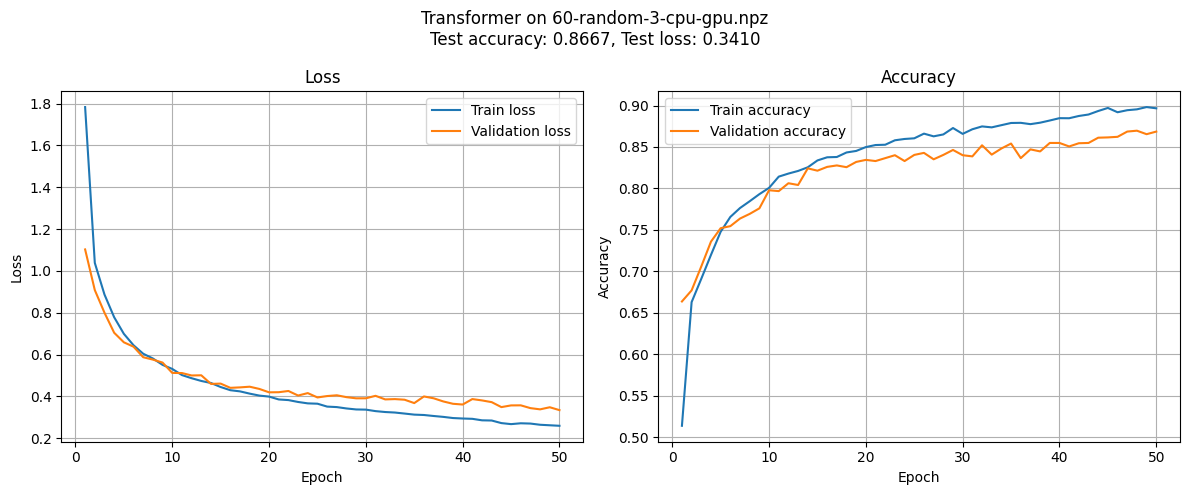

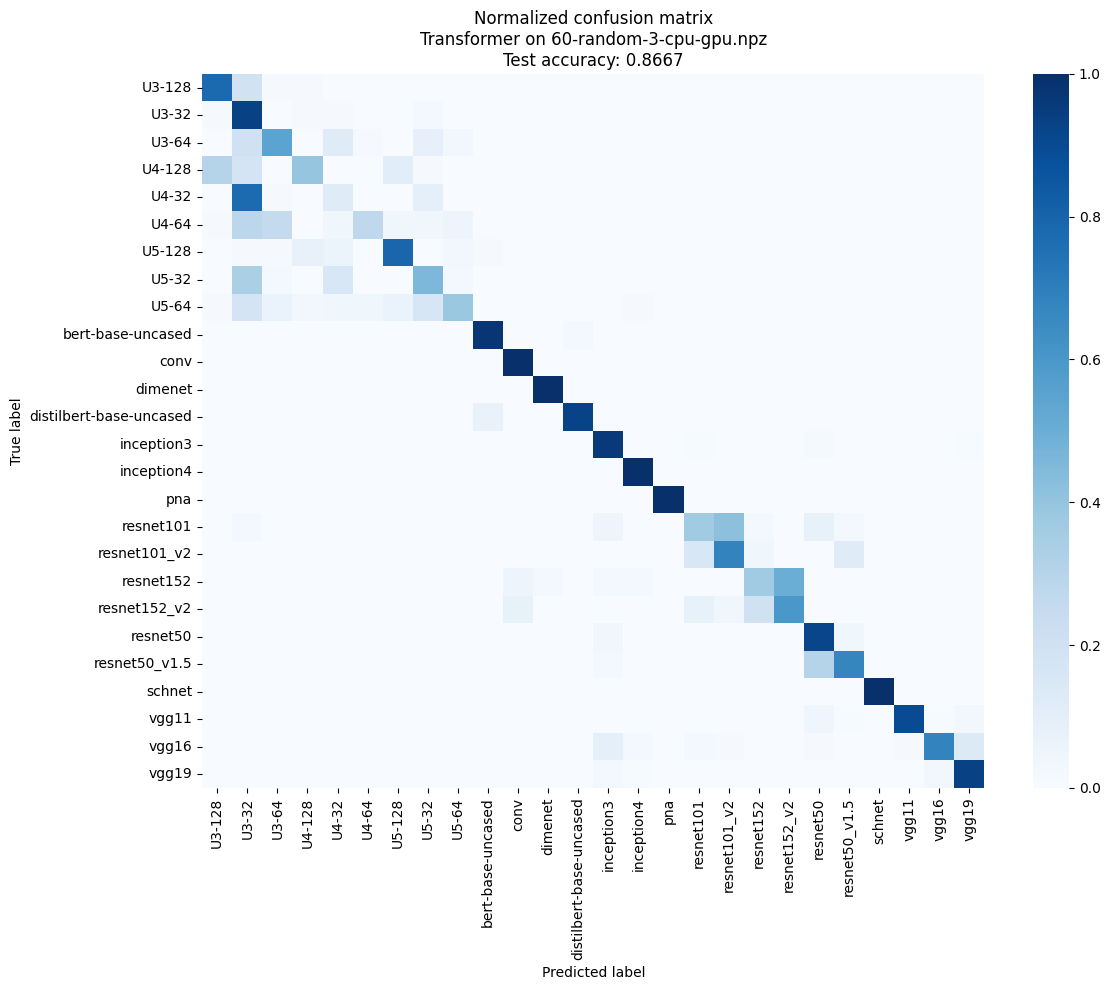

Worst run:
Model: Transformer
Dataset: 60-start-1-cpu-gpu.npz
Test accuracy: 0.784265350877193
Test loss: 0.5433808983417979



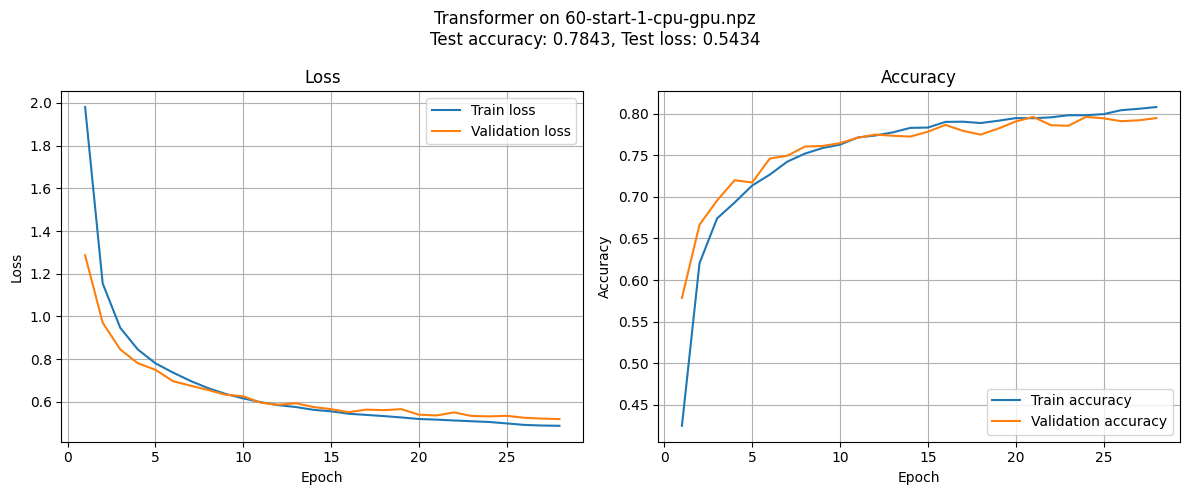

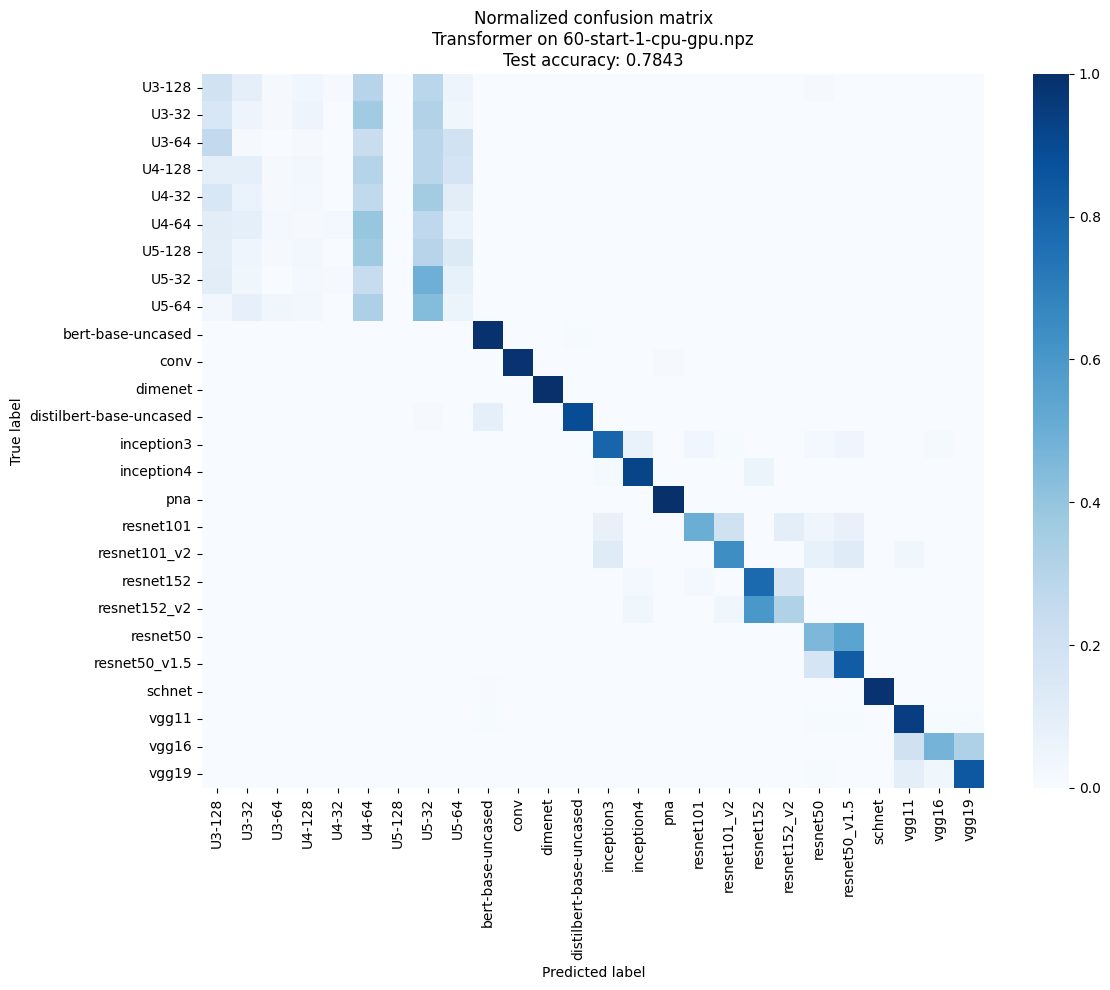

In [47]:
best_result, worst_result = plot_best_and_worst_runs(
    results_transformer,
    metric="test_acc",
    class_names=class_names_combined,
    normalize_cm=True,
)

### Two Tower Transformer

In [48]:
results_two_tower = main(
    dataset_ls=combined_datasets,
    model_builder=build_two_tower_model,
    model_name="TwoTowerTransformer",
    separate=False,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

/tmp/ipykernel_11957/3989711177.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.gpu_encoder = nn.TransformerEncoder(
/tmp/ipykernel_11957/3989711177.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cpu_encoder = nn.TransformerEncoder(


Training TwoTowerTransformer on 60-start-1-cpu-gpu.npz


100%|██████████| 92/92 [00:00<00:00, 177.50it/s]


Epoch [1/50] | Time: 6.37s
Train Loss: 1.8846 | Train Accuracy: 0.4506
Val Loss:   1.2073 | Val Accuracy:   0.6220


100%|██████████| 92/92 [00:00<00:00, 179.99it/s]


...

Epoch [41/50] | Time: 6.16s
Train Loss: 0.2501 | Train Accuracy: 0.9015
Val Loss:   0.3817 | Val Accuracy:   0.8636


100%|██████████| 89/89 [00:00<00:00, 173.86it/s]


Epoch [46/50] | Time: 6.18s
Train Loss: 0.2461 | Train Accuracy: 0.9014
Val Loss:   0.3835 | Val Accuracy:   0.8636


100%|██████████| 111/111 [00:00<00:00, 176.72it/s]


Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/TwoTowerTransformer_60-random-5-cpu-gpu.pt
Test accuracy: 0.8762
--------------------------------------------------------------------------------


Best run:
Model: TwoTowerTransformer
Dataset: 60-random-3-cpu-gpu.npz
Test accuracy: 0.883629191321499
Test loss: 0.29339004466485963



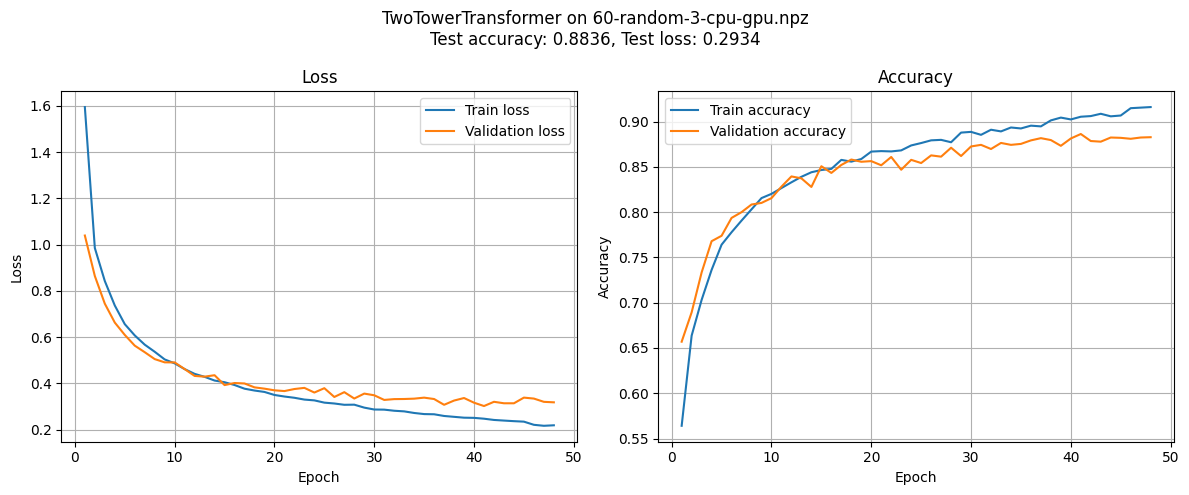

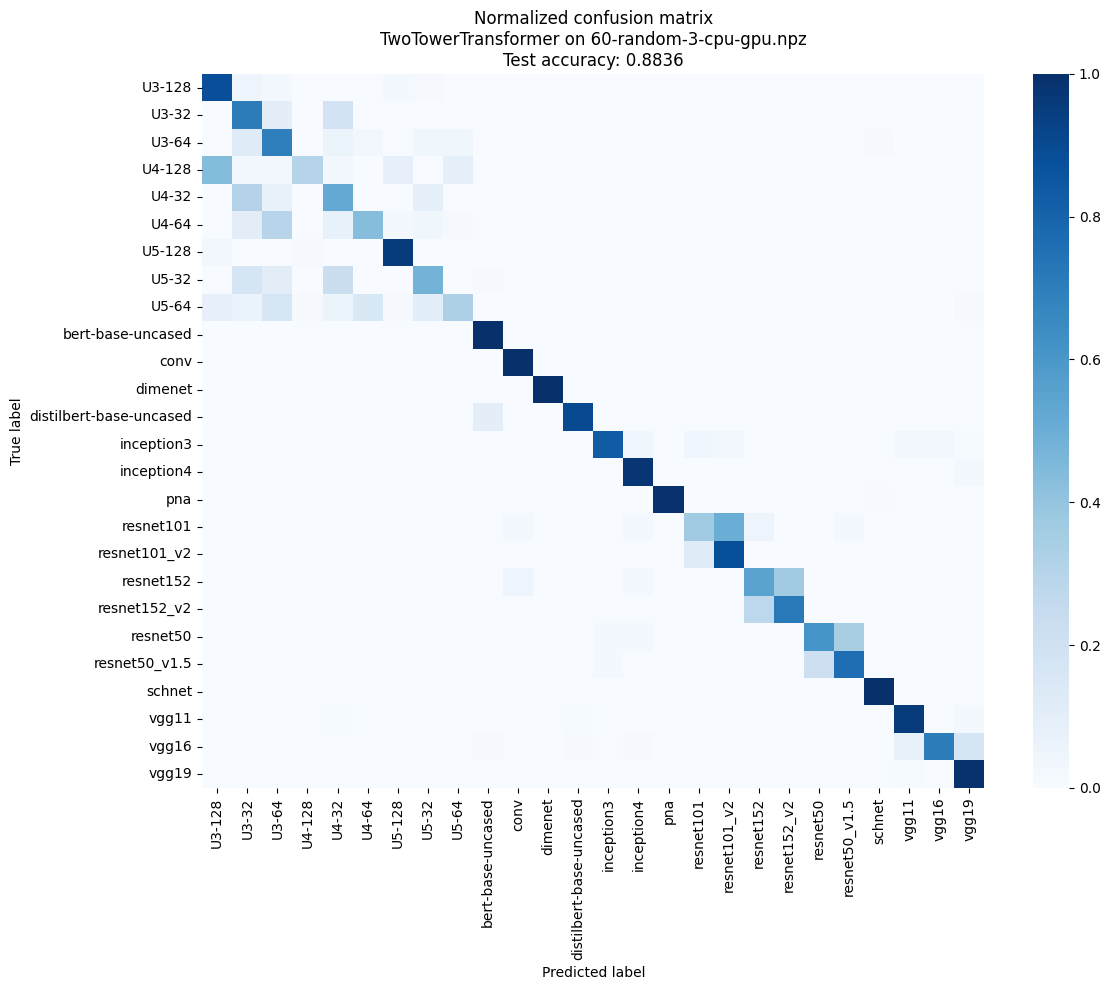

Worst run:
Model: TwoTowerTransformer
Dataset: 60-start-1-cpu-gpu.npz
Test accuracy: 0.8075657894736842
Test loss: 0.49280209715167683



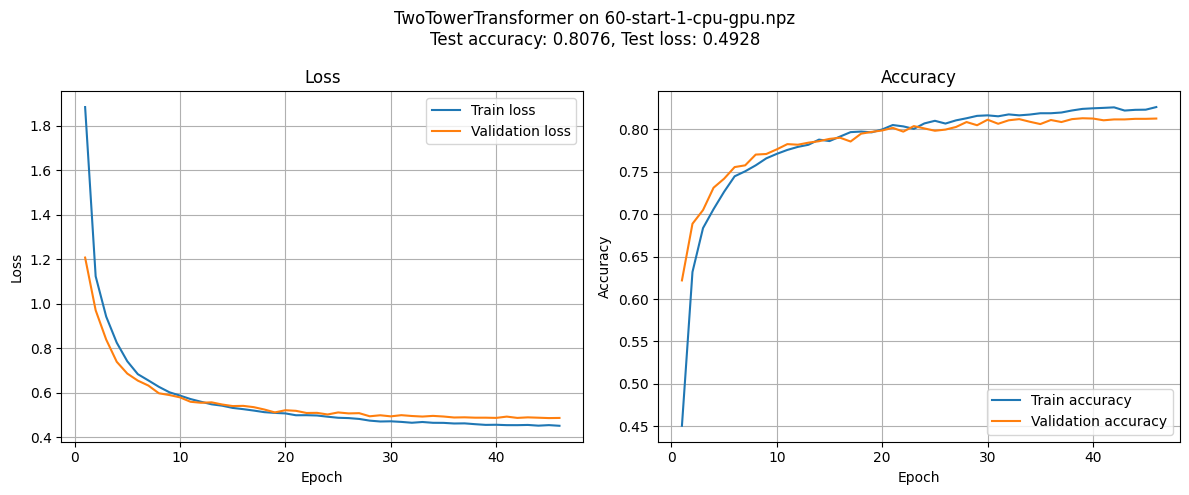

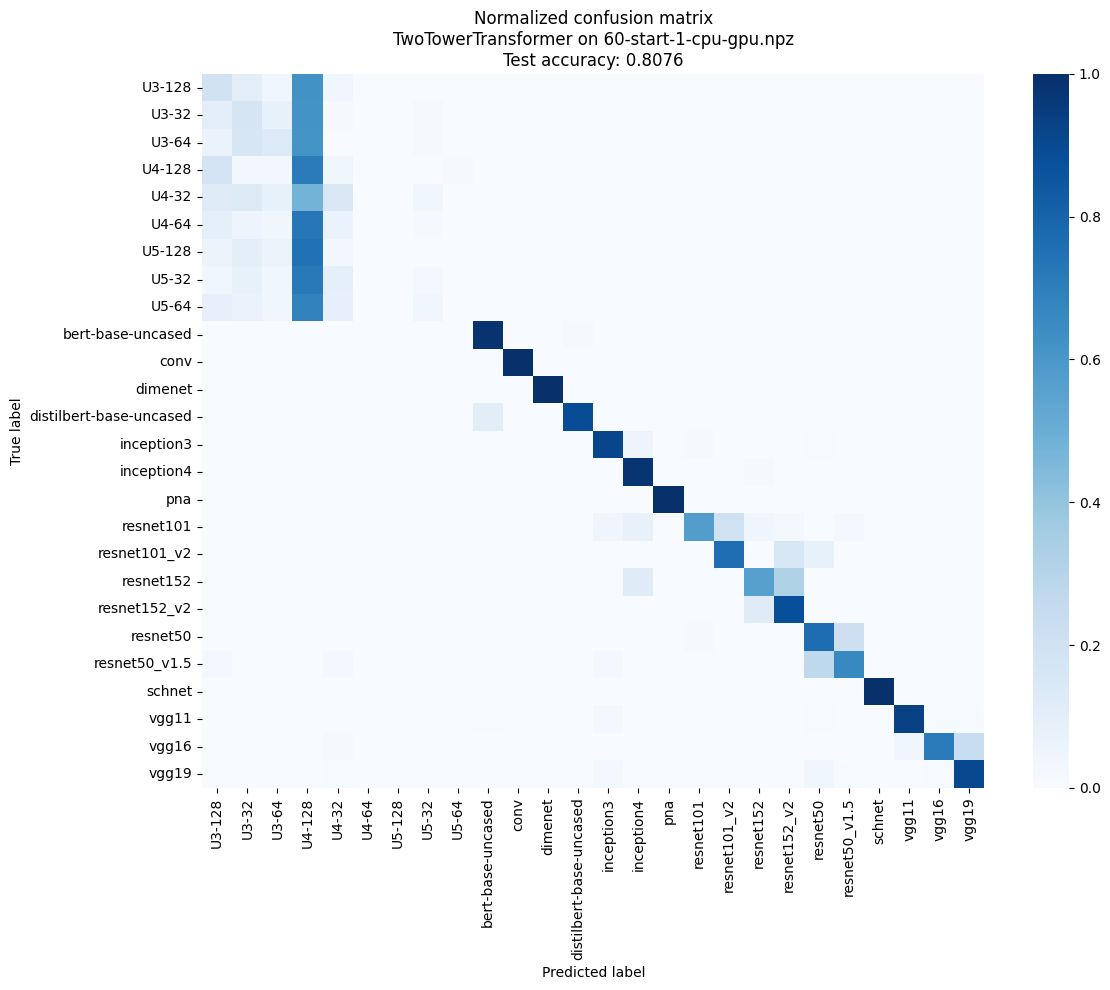

In [49]:
best_result, worst_result = plot_best_and_worst_runs(
    results_two_tower,
    metric="test_acc",
    class_names=class_names_combined,
    normalize_cm=True,
)

### Gated Two Tower Transformer

In [50]:
results_gated = main(
    dataset_ls=separated_datasets,
    model_builder=build_gated_two_tower_model,
    model_name="GatedTwoTowerTransformer",
    separate=True,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

/tmp/ipykernel_11957/2831501508.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.gpu_transformer = nn.TransformerEncoder(
/tmp/ipykernel_11957/2831501508.py:91: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cpu_transformer = nn.TransformerEncoder(


Training GatedTwoTowerTransformer on 60-start-1-separate-cpu-gpu.npz


100%|██████████| 92/92 [00:00<00:00, 281.52it/s]


Epoch [1/50] | Time: 5.67s
Train Loss: 1.9280 | Train Accuracy: 0.4507
Val Loss:   1.2268 | Val Accuracy:   0.6162


100%|██████████| 92/92 [00:00<00:00, 282.03it/s]


...

Epoch [31/50] | Time: 5.49s
Train Loss: 0.2464 | Train Accuracy: 0.9010
Val Loss:   0.3824 | Val Accuracy:   0.8453


100%|██████████| 89/89 [00:00<00:00, 283.04it/s]


Epoch [36/50] | Time: 5.52s
Train Loss: 0.2312 | Train Accuracy: 0.9088
Val Loss:   0.3773 | Val Accuracy:   0.8485
Early stopping on epoch 36
Best validation accuracy: 84.85%


100%|██████████| 111/111 [00:00<00:00, 283.74it/s]


Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/GatedTwoTowerTransformer_60-random-5-separate-cpu-gpu.pt
Test accuracy: 0.8534
--------------------------------------------------------------------------------


Best run:
Model: GatedTwoTowerTransformer
Dataset: 60-middle-1-separate-cpu-gpu.npz
Test accuracy: 0.8916713562183455
Test loss: 0.269611731582501



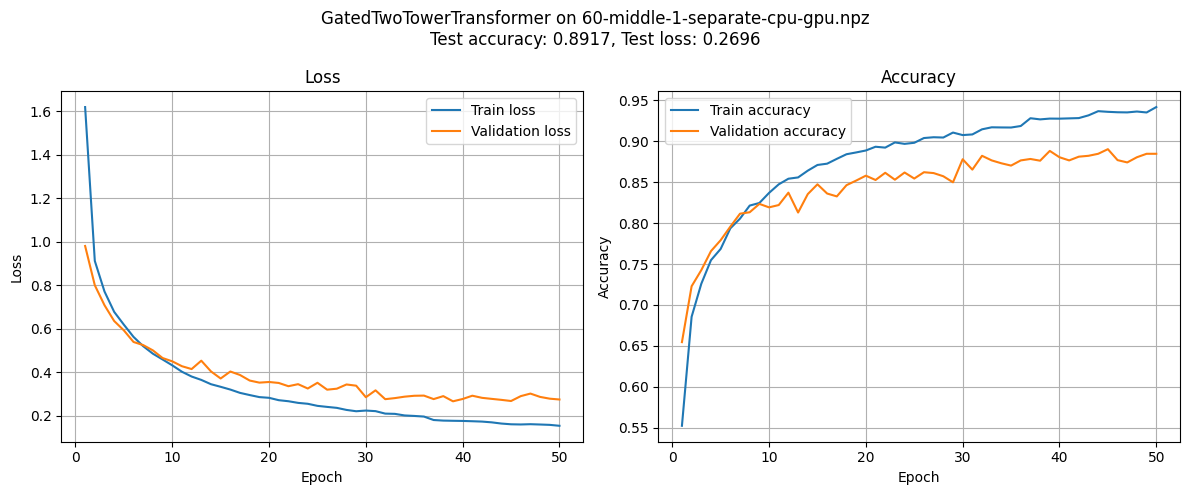

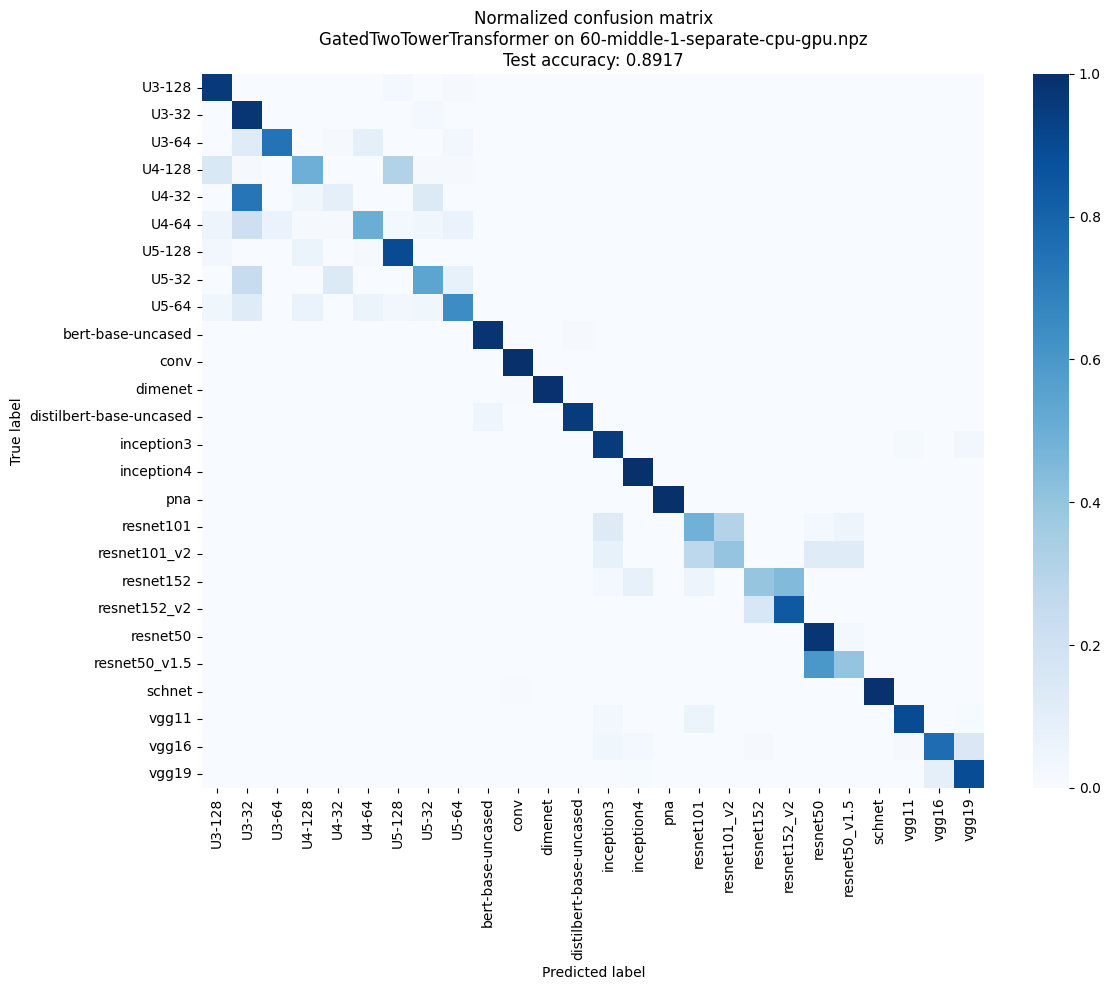

Worst run:
Model: GatedTwoTowerTransformer
Dataset: 60-start-1-separate-cpu-gpu.npz
Test accuracy: 0.8020833333333334
Test loss: 0.5147716422614298



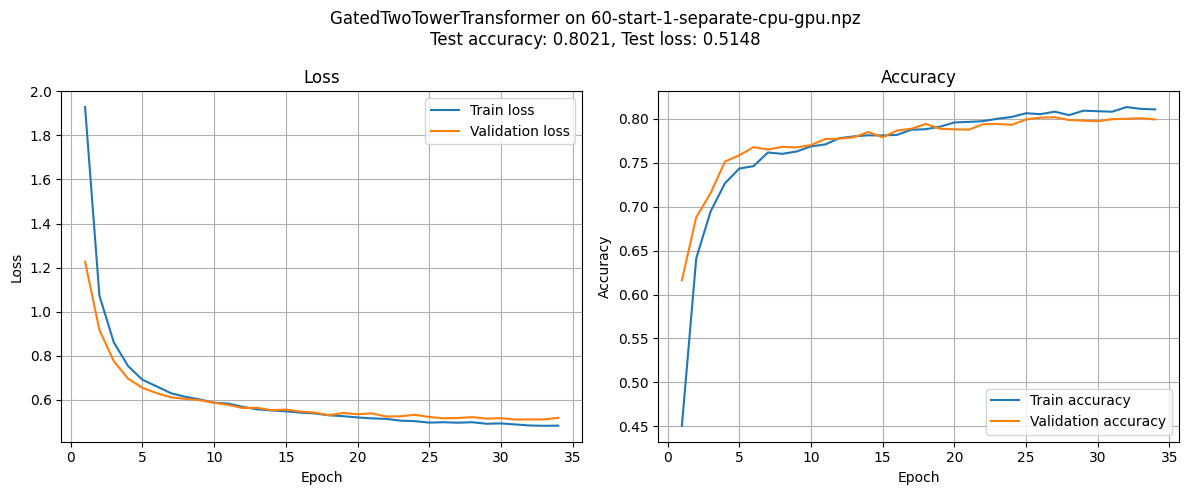

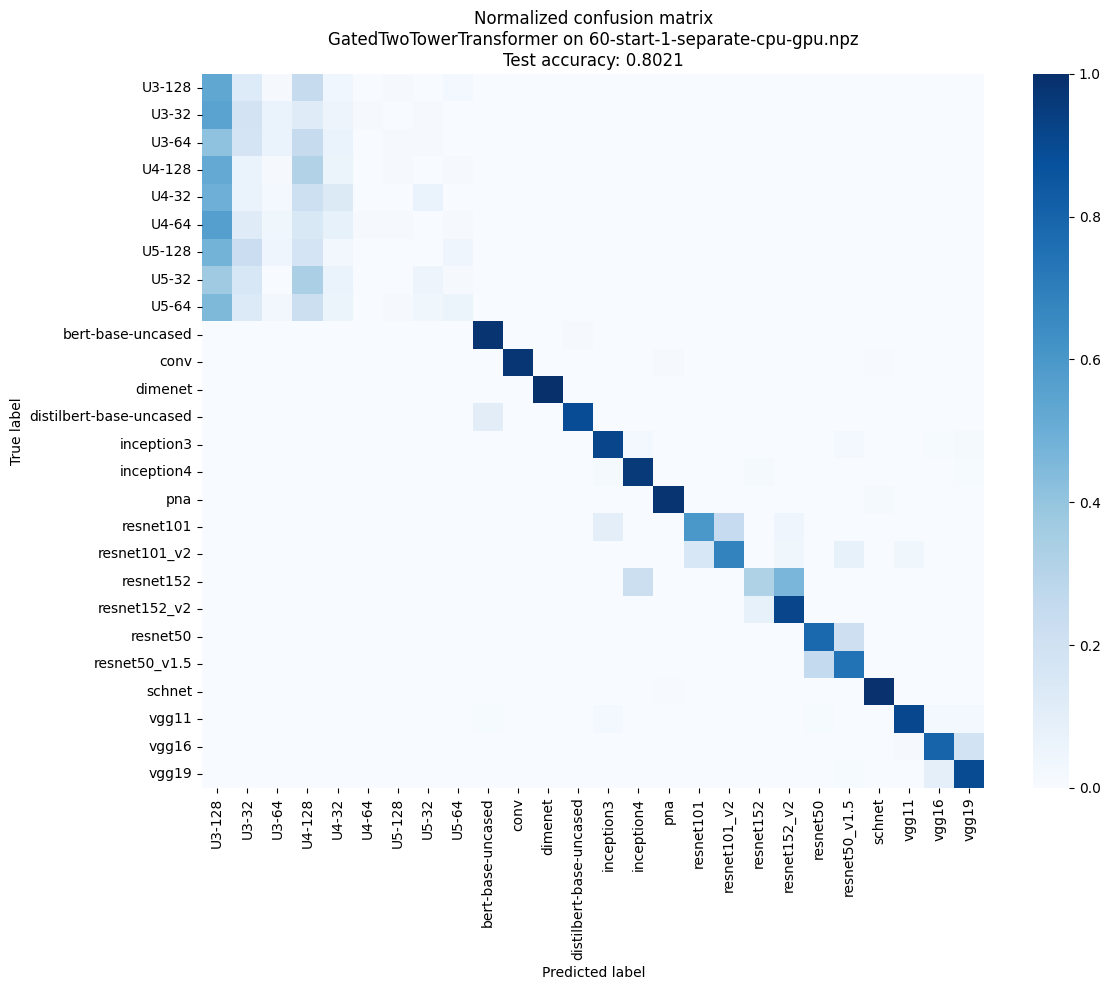

In [51]:
best_result, worst_result = plot_best_and_worst_runs(
    results_gated,
    metric="test_acc",
    class_names=class_names_separate,
    normalize_cm=True,
)

In [52]:
all_results = results_transformer + results_two_tower + results_gated

In [53]:
summary_df = results_to_dataframe(all_results)
summary_df

,model_name,dataset_name,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run
15,GatedTwoTowerTransformer,60-middle-1-separate-cpu-gpu.npz,0.891671,0.269612,0.890257,0.884629,0.941689,50
11,TwoTowerTransformer,60-random-3-cpu-gpu.npz,0.883629,0.293390,0.886228,0.882705,0.915969,48
8,TwoTowerTransformer,60-middle-1-cpu-gpu.npz,0.878447,0.322435,0.886388,0.881463,0.924362,47
13,TwoTowerTransformer,60-random-5-cpu-gpu.npz,0.876233,0.365879,0.869626,0.855180,0.904388,50
4,Transformer,60-random-3-cpu-gpu.npz,0.866723,0.340980,0.869672,0.868616,0.896679,50
12,TwoTowerTransformer,60-random-4-cpu-gpu.npz,0.864880,0.357081,0.868124,0.866714,0.896588,32
9,TwoTowerTransformer,60-random-1-cpu-gpu.npz,0.864636,0.351098,0.874868,0.872753,0.899427,50
3,Transformer,60-random-2-cpu-gpu.npz,0.862059,0.373127,0.865303,0.862130,0.891749,50
10,TwoTowerTransformer,60-random-2-cpu-gpu.npz,0.857828,0.385393,0.866714,0.863188,0.912112,47
20,GatedTwoTowerTransformer,60-random-5-separate-cpu-gpu.npz,0.853397,0.361427,0.848485,0.848485,0.908795,36


In [54]:
summary_df.groupby("model_name").mean("test_acc").sort_values("test_acc", ascending=False)

,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run
model_name,,,,,,
TwoTowerTransformer,0.861888,0.366868,0.866454,0.862127,0.897039,45.714286
Transformer,0.839278,0.411766,0.842622,0.840363,0.873420,41.714286
GatedTwoTowerTransformer,0.838227,0.407381,0.839163,0.833031,0.885202,33.571429


How does increasing timeseries affect results?
- If RNNs performm is comparable

Looking at attention layers, attention weights, attention matrix / map
-- how sparse is it? what does it pay attention to

Try GRU / LSTMS or RNNs
-- cold start problem -- Transformers may face this problem

Efficiency and running time

Pre-Trained transformer? Open-Source Model
- Using a LLM to frame your approach
- Recasting data
